In [1]:
import util
#from models import EEGNet, EEGNet_TF, EEGNet_Wavelet

from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from tensorflow.keras import utils as np_utils
from scipy.signal import stft
from pyriemann.utils.viz import plot_confusion_matrix
import pywt
import sys
import numpy

['/Users/bobbeashel/Desktop/CITS4010/Project', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python38.zip', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/lib-dynload', '', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages', '/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master']
1.24.3


In [2]:
sys.path.append("/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master")
print(sys.path)

"""
 ARL_EEGModels - A collection of Convolutional Neural Network models for EEG
 Signal Processing and Classification, using Keras and Tensorflow

 Requirements:
    (1) tensorflow == 2.X (as of this writing, 2.0 - 2.3 have been verified
        as working)
 
 To run the EEG/MEG ERP classification sample script, you will also need

    (4) mne >= 0.17.1
    (5) PyRiemann >= 0.2.5
    (6) scikit-learn >= 0.20.1
    (7) matplotlib >= 2.2.3
    
 To use:
    
    (1) Place this file in the PYTHONPATH variable in your IDE (i.e.: Spyder)
    (2) Import the model as
        
        from EEGModels import EEGNet    
        
        model = EEGNet(nb_classes = ..., Chans = ..., Samples = ...)
        
    (3) Then compile and fit the model
    
        model.compile(loss = ..., optimizer = ..., metrics = ...)
        fitted    = model.fit(...)
        predicted = model.predict(...)

 Portions of this project are works of the United States Government and are not
 subject to domestic copyright protection under 17 USC Sec. 105.  Those 
 portions are released world-wide under the terms of the Creative Commons Zero 
 1.0 (CC0) license.  
 
 Other portions of this project are subject to domestic copyright protection 
 under 17 USC Sec. 105.  Those portions are licensed under the Apache 2.0 
 license.  The complete text of the license governing this material is in 
 the file labeled LICENSE.TXT that is a part of this project's official 
 distribution. 
"""

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Permute, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K

def EEGNet_Wavelet3(nb_classes, Chans=22, Frequencies=30, Samples=500,
                   dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16,
                   norm_rate=0.25, dropoutType='Dropout'):
    # Input shape: (Channels, Frequencies, Time)
    input_layer = Input(shape=(Frequencies, Samples, Chans))
    x = Conv2D(16, (4, 4), padding='same', kernel_initializer='he_normal', name='conv2d_1')(input_layer)
    x = Activation('relu', name='activation_1')(x)
    x = MaxPooling2D(pool_size=(8, 8), name='maxpool2d_1')(x)
    x = Dropout(0.25, name='dropout_1')(x)

    x = Conv2D(32, (4, 4), padding='same', kernel_initializer='he_normal', name='conv2d_2')(x)
    x = Activation('relu', name='activation_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='maxpool2d_2')(x)
    x = Dropout(0.25, name='dropout_2')(x)

    x = Flatten(name='flatten_1')(x)
    x = Dense(240, kernel_initializer='he_normal', name='dense_1')(x)
    x = Activation('relu', name='activation_3')(x)
    x = Dropout(0.5, name='dropout_3')(x)

    x = Dense(nb_classes, kernel_initializer='he_normal', name='dense_2')(x)
    output_layer = Activation('softmax', name='activation_4')(x)

    model = Model(inputs=input_layer, outputs=output_layer, name='my_cnn_model')
    model.summary()

    return Model(inputs=input_layer, outputs=output_layer)

def EEGNet_Wavelet2(nb_classes, Chans=22, Frequencies=30, Samples=500,
                   dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16,
                   norm_rate=0.25, dropoutType='Dropout'):

    if dropoutType == 'SpatialDropout2D':
        dropoutType = SpatialDropout2D
    elif dropoutType == 'Dropout':
        dropoutType = Dropout
    else:
        raise ValueError("dropoutType must be 'Dropout' or 'SpatialDropout2D'")

    # Input shape: (Channels, Frequencies, Time)
    input1 = Input(shape=(Frequencies, Samples, Chans))

    # Temporal convolution (across time)
    block1 = Conv2D(F1, (1, kernLength), padding='same', use_bias=False, data_format='channels_last')(input1)
    block1 = BatchNormalization(axis=1)(block1)

    # Depthwise convolution (across channels)
    block1 = DepthwiseConv2D((1, 1), use_bias=False,
                             depth_multiplier=D,
                             depthwise_constraint=max_norm(1.),
                             data_format='channels_last')(block1)
    block1 = BatchNormalization(axis=1)(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4), data_format='channels_last')(block1)
    block1 = dropoutType(dropoutRate)(block1)

    # Separable convolution (across freqs and time)
    block2 = SeparableConv2D(F2, (1, 16), padding='same', use_bias=False, data_format='channels_last')(block1)
    block2 = BatchNormalization(axis=1)(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 4), data_format='channels_last')(block2)
    block2 = dropoutType(dropoutRate)(block2)

    flatten = Flatten(name='flatten')(block2)
    dense = Dense(nb_classes, kernel_constraint=max_norm(norm_rate), name='dense')(flatten)
    softmax = Activation('softmax', name='softmax')(dense)

    return Model(inputs=input1, outputs=softmax)

def EEGNet_TF(
    nb_classes,
    Chans,
    FreqBins,
    TimeWindows,
    dropoutRate=0.5,
    kernLength=64,
    F1=8,
    D=2,
    F2=None,
    norm_rate=0.25,
    dropoutType='Dropout'
):
    """EEGNet adapted for time-frequency inputs (channels_first)

    Parameters:
      nb_classes   : number of output classes
      Chans        : number of EEG channels (input channels)
      FreqBins     : number of frequency bins (height)
      TimeWindows  : number of time windows (width)
      dropoutRate  : dropout fraction
      kernLength   : temporal kernel length (time axis)
      F1, D        : temporal filters and depth multiplier
      F2           : separable filters (defaults to F1*D)
      norm_rate    : max-norm constraint for dense
      dropoutType  : 'Dropout' or 'SpatialDropout2D'

    Input tensor shape (channels_first): (Chans, FreqBins, TimeWindows)
    """
    # default for F2
    F2 = F2 or (F1 * D)

    # select dropout class
    if dropoutType == 'SpatialDropout2D':
        dropoutType = SpatialDropout2D
    elif dropoutType == 'Dropout':
        dropoutType = Dropout
    else:
        raise ValueError('dropoutType must be one of SpatialDropout2D '
                         'or Dropout, passed as a string.')

    # input layer: channels_first
    input1 = Input(shape=(Chans, FreqBins, TimeWindows))
    '''
    # Block 1: temporal convolution across time windows, per frequency, per channel
    x = Conv2D(
        filters=F1,
        kernel_size=(1, kernLength),
        padding='same',
        use_bias=False,
        data_format='channels_first'
    )(input1)
    x = BatchNormalization(axis=1)(x)'''

    # depthwise convolution across channels to learn spatial filters
    block1       = Conv2D(F1, (1, kernLength), padding = 'same', input_shape = (1, Chans, FreqBins, TimeWindows), use_bias = False)(input1)
    block1       = BatchNormalization()(block1)
    block1       = DepthwiseConv2D((Chans, 1), use_bias = False, 
                                   depth_multiplier = D,
                                   depthwise_constraint = max_norm(1.))(block1)
    block1       = BatchNormalization()(block1)
    block1       = Activation('elu')(block1)
    block1       = AveragePooling2D((1, 4))(block1)
    block1       = dropoutType(dropoutRate)(block1)

    block2       = SeparableConv2D(F2, (1, 16),
                                   use_bias = False, padding = 'same')(block1)
    block2       = BatchNormalization()(block2)
    block2       = Activation('elu')(block2)
    block2       = AveragePooling2D((1, 4))(block2) # CHANGED FROM 1,8 -> 1,4
    block2       = dropoutType(dropoutRate)(block2)
        
    flatten      = Flatten(name = 'flatten')(block2)
    
    dense        = Dense(nb_classes, name = 'dense', 
                         kernel_constraint = max_norm(norm_rate))(flatten)
    softmax      = Activation('softmax', name = 'softmax')(dense)
    
    return Model(inputs=input1, outputs=softmax)

def EEGNet(nb_classes, Chans = 64, Samples = 128, 
             dropoutRate = 0.5, kernLength = 64, F1 = 8, 
             D = 2, F2 = 16, norm_rate = 0.25, dropoutType = 'SpatialDropout2D'):
    """ Keras Implementation of EEGNet
    http://iopscience.iop.org/article/10.1088/1741-2552/aace8c/meta

    Note that this implements the newest version of EEGNet and NOT the earlier
    version (version v1 and v2 on arxiv). We strongly recommend using this
    architecture as it performs much better and has nicer properties than
    our earlier version. For example:
        
        1. Depthwise Convolutions to learn spatial filters within a 
        temporal convolution. The use of the depth_multiplier option maps 
        exactly to the number of spatial filters learned within a temporal
        filter. This matches the setup of algorithms like FBCSP which learn 
        spatial filters within each filter in a filter-bank. This also limits 
        the number of free parameters to fit when compared to a fully-connected
        convolution. 
        
        2. Separable Convolutions to learn how to optimally combine spatial
        filters across temporal bands. Separable Convolutions are Depthwise
        Convolutions followed by (1x1) Pointwise Convolutions. 
        
    
    While the original paper used Dropout, we found that SpatialDropout2D 
    sometimes produced slightly better results for classification of ERP 
    signals. However, SpatialDropout2D significantly reduced performance 
    on the Oscillatory dataset (SMR, BCI-IV Dataset 2A). We recommend using
    the default Dropout in most cases.
        
    Assumes the input signal is sampled at 128Hz. If you want to use this model
    for any other sampling rate you will need to modify the lengths of temporal
    kernels and average pooling size in blocks 1 and 2 as needed (double the 
    kernel lengths for double the sampling rate, etc). Note that we haven't 
    tested the model performance with this rule so this may not work well. 
    
    The model with default parameters gives the EEGNet-8,2 model as discussed
    in the paper. This model should do pretty well in general, although it is
	advised to do some model searching to get optimal performance on your
	particular dataset.

    We set F2 = F1 * D (number of input filters = number of output filters) for
    the SeparableConv2D layer. We haven't extensively tested other values of this
    parameter (say, F2 < F1 * D for compressed learning, and F2 > F1 * D for
    overcomplete). We believe the main parameters to focus on are F1 and D. 

    Inputs:
        
      nb_classes      : int, number of classes to classify
      Chans, Samples  : number of channels and time points in the EEG data
      dropoutRate     : dropout fraction
      kernLength      : length of temporal convolution in first layer. We found
                        that setting this to be half the sampling rate worked
                        well in practice. For the SMR dataset in particular
                        since the data was high-passed at 4Hz we used a kernel
                        length of 32.     
      F1, F2          : number of temporal filters (F1) and number of pointwise
                        filters (F2) to learn. Default: F1 = 8, F2 = F1 * D. 
      D               : number of spatial filters to learn within each temporal
                        convolution. Default: D = 2
      dropoutType     : Either SpatialDropout2D or Dropout, passed as a string.

    """
    
    if dropoutType == 'SpatialDropout2D':
        dropoutType = SpatialDropout2D
    elif dropoutType == 'Dropout':
        dropoutType = Dropout
    else:
        raise ValueError('dropoutType must be one of SpatialDropout2D '
                         'or Dropout, passed as a string.')
    
    input1   = Input(shape = (Chans, Samples, 1))

    ##################################################################
    block1       = Conv2D(F1, (1, kernLength), padding = 'same',
                                   input_shape = (Chans, Samples, 1),
                                   use_bias = False)(input1)
    block1       = BatchNormalization()(block1)
    block1       = DepthwiseConv2D((Chans, 1), use_bias = False, 
                                   depth_multiplier = D,
                                   depthwise_constraint = max_norm(1.))(block1)
    block1       = BatchNormalization()(block1)
    block1       = Activation('elu')(block1)
    block1       = AveragePooling2D((1, 4))(block1)
    block1       = dropoutType(dropoutRate)(block1)
    
    block2       = SeparableConv2D(F2, (1, 16),
                                   use_bias = False, padding = 'same')(block1)
    block2       = BatchNormalization()(block2)
    block2       = Activation('elu')(block2)
    block2       = AveragePooling2D((1, 8))(block2)
    block2       = dropoutType(dropoutRate)(block2)
        
    flatten      = Flatten(name = 'flatten')(block2)
    
    dense        = Dense(nb_classes, name = 'dense', 
                         kernel_constraint = max_norm(norm_rate))(flatten)
    softmax      = Activation('softmax', name = 'softmax')(dense)
    
    return Model(inputs=input1, outputs=softmax)




def EEGNet_SSVEP(nb_classes = 12, Chans = 8, Samples = 256, 
             dropoutRate = 0.5, kernLength = 256, F1 = 96, 
             D = 1, F2 = 96, dropoutType = 'Dropout'):
    """ SSVEP Variant of EEGNet, as used in [1]. 

    Inputs:
        
      nb_classes      : int, number of classes to classify
      Chans, Samples  : number of channels and time points in the EEG data
      dropoutRate     : dropout fraction
      kernLength      : length of temporal convolution in first layer
      F1, F2          : number of temporal filters (F1) and number of pointwise
                        filters (F2) to learn. 
      D               : number of spatial filters to learn within each temporal
                        convolution.
      dropoutType     : Either SpatialDropout2D or Dropout, passed as a string.
      
      
    [1]. Waytowich, N. et. al. (2018). Compact Convolutional Neural Networks
    for Classification of Asynchronous Steady-State Visual Evoked Potentials.
    Journal of Neural Engineering vol. 15(6). 
    http://iopscience.iop.org/article/10.1088/1741-2552/aae5d8

    """
    
    if dropoutType == 'SpatialDropout2D':
        dropoutType = SpatialDropout2D
    elif dropoutType == 'Dropout':
        dropoutType = Dropout
    else:
        raise ValueError('dropoutType must be one of SpatialDropout2D '
                         'or Dropout, passed as a string.')
    
    input1   = Input(shape = (Chans, Samples, 1))

    ##################################################################
    block1       = Conv2D(F1, (1, kernLength), padding = 'same',
                                   input_shape = (Chans, Samples, 1),
                                   use_bias = False)(input1)
    block1       = BatchNormalization()(block1)
    block1       = DepthwiseConv2D((Chans, 1), use_bias = False, 
                                   depth_multiplier = D,
                                   depthwise_constraint = max_norm(1.))(block1)
    block1       = BatchNormalization()(block1)
    block1       = Activation('elu')(block1)
    block1       = AveragePooling2D((1, 4))(block1)
    block1       = dropoutType(dropoutRate)(block1)
    
    block2       = SeparableConv2D(F2, (1, 16),
                                   use_bias = False, padding = 'same')(block1)
    block2       = BatchNormalization()(block2)
    block2       = Activation('elu')(block2)
    block2       = AveragePooling2D((1, 8))(block2)
    block2       = dropoutType(dropoutRate)(block2)
        
    flatten      = Flatten(name = 'flatten')(block2)
    
    dense        = Dense(nb_classes, name = 'dense')(flatten)
    softmax      = Activation('softmax', name = 'softmax')(dense)
    
    return Model(inputs=input1, outputs=softmax)



def EEGNet_old(nb_classes, Chans = 64, Samples = 128, regRate = 0.0001,
           dropoutRate = 0.25, kernels = [(2, 32), (8, 4)], strides = (2, 4)):
    """ Keras Implementation of EEGNet_v1 (https://arxiv.org/abs/1611.08024v2)

    This model is the original EEGNet model proposed on arxiv
            https://arxiv.org/abs/1611.08024v2
    
    with a few modifications: we use striding instead of max-pooling as this 
    helped slightly in classification performance while also providing a 
    computational speed-up. 
    
    Note that we no longer recommend the use of this architecture, as the new
    version of EEGNet performs much better overall and has nicer properties.
    
    Inputs:
        
        nb_classes     : total number of final categories
        Chans, Samples : number of EEG channels and samples, respectively
        regRate        : regularization rate for L1 and L2 regularizations
        dropoutRate    : dropout fraction
        kernels        : the 2nd and 3rd layer kernel dimensions (default is 
                         the [2, 32] x [8, 4] configuration)
        strides        : the stride size (note that this replaces the max-pool
                         used in the original paper)
    
    """

    # start the model
    input_main   = Input((Chans, Samples))
    layer1       = Conv2D(16, (Chans, 1), input_shape=(Chans, Samples, 1),
                                 kernel_regularizer = l1_l2(l1=regRate, l2=regRate))(input_main)
    layer1       = BatchNormalization()(layer1)
    layer1       = Activation('elu')(layer1)
    layer1       = Dropout(dropoutRate)(layer1)
    
    permute_dims = 2, 1, 3
    permute1     = Permute(permute_dims)(layer1)
    
    layer2       = Conv2D(4, kernels[0], padding = 'same', 
                            kernel_regularizer=l1_l2(l1=0.0, l2=regRate),
                            strides = strides)(permute1)
    layer2       = BatchNormalization()(layer2)
    layer2       = Activation('elu')(layer2)
    layer2       = Dropout(dropoutRate)(layer2)
    
    layer3       = Conv2D(4, kernels[1], padding = 'same',
                            kernel_regularizer=l1_l2(l1=0.0, l2=regRate),
                            strides = strides)(layer2)
    layer3       = BatchNormalization()(layer3)
    layer3       = Activation('elu')(layer3)
    layer3       = Dropout(dropoutRate)(layer3)
    
    flatten      = Flatten(name = 'flatten')(layer3)
    
    dense        = Dense(nb_classes, name = 'dense')(flatten)
    softmax      = Activation('softmax', name = 'softmax')(dense)
    
    return Model(inputs=input_main, outputs=softmax)



def DeepConvNet(nb_classes, Chans = 64, Samples = 256,
                dropoutRate = 0.5):
    """ Keras implementation of the Deep Convolutional Network as described in
    Schirrmeister et. al. (2017), Human Brain Mapping.
    
    This implementation assumes the input is a 2-second EEG signal sampled at 
    128Hz, as opposed to signals sampled at 250Hz as described in the original
    paper. We also perform temporal convolutions of length (1, 5) as opposed
    to (1, 10) due to this sampling rate difference. 
    
    Note that we use the max_norm constraint on all convolutional layers, as 
    well as the classification layer. We also change the defaults for the
    BatchNormalization layer. We used this based on a personal communication 
    with the original authors.
    
                      ours        original paper
    pool_size        1, 2        1, 3
    strides          1, 2        1, 3
    conv filters     1, 5        1, 10
    
    Note that this implementation has not been verified by the original 
    authors. 
    
    """

    # start the model
    input_main   = Input((Chans, Samples, 1))
    block1       = Conv2D(25, (1, 5), 
                                 input_shape=(Chans, Samples, 1),
                                 kernel_constraint = max_norm(2., axis=(0,1,2)))(input_main)
    block1       = Conv2D(25, (Chans, 1),
                                 kernel_constraint = max_norm(2., axis=(0,1,2)))(block1)
    block1       = BatchNormalization(epsilon=1e-05, momentum=0.9)(block1)
    block1       = Activation('elu')(block1)
    block1       = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block1)
    block1       = Dropout(dropoutRate)(block1)
  
    block2       = Conv2D(50, (1, 5),
                                 kernel_constraint = max_norm(2., axis=(0,1,2)))(block1)
    block2       = BatchNormalization(epsilon=1e-05, momentum=0.9)(block2)
    block2       = Activation('elu')(block2)
    block2       = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block2)
    block2       = Dropout(dropoutRate)(block2)
    
    block3       = Conv2D(100, (1, 5),
                                 kernel_constraint = max_norm(2., axis=(0,1,2)))(block2)
    block3       = BatchNormalization(epsilon=1e-05, momentum=0.9)(block3)
    block3       = Activation('elu')(block3)
    block3       = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block3)
    block3       = Dropout(dropoutRate)(block3)
    
    block4       = Conv2D(200, (1, 5),
                                 kernel_constraint = max_norm(2., axis=(0,1,2)))(block3)
    block4       = BatchNormalization(epsilon=1e-05, momentum=0.9)(block4)
    block4       = Activation('elu')(block4)
    block4       = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block4)
    block4       = Dropout(dropoutRate)(block4)
    
    flatten      = Flatten()(block4)
    
    dense        = Dense(nb_classes, kernel_constraint = max_norm(0.5))(flatten)
    softmax      = Activation('softmax')(dense)
    
    return Model(inputs=input_main, outputs=softmax)


# need these for ShallowConvNet
def square(x):
    return K.square(x)

def log(x):
    return K.log(K.clip(x, min_value = 1e-7, max_value = 10000))   


def ShallowConvNet(nb_classes, Chans = 64, Samples = 128, dropoutRate = 0.5):
    """ Keras implementation of the Shallow Convolutional Network as described
    in Schirrmeister et. al. (2017), Human Brain Mapping.
    
    Assumes the input is a 2-second EEG signal sampled at 128Hz. Note that in 
    the original paper, they do temporal convolutions of length 25 for EEG
    data sampled at 250Hz. We instead use length 13 since the sampling rate is 
    roughly half of the 250Hz which the paper used. The pool_size and stride
    in later layers is also approximately half of what is used in the paper.
    
    Note that we use the max_norm constraint on all convolutional layers, as 
    well as the classification layer. We also change the defaults for the
    BatchNormalization layer. We used this based on a personal communication 
    with the original authors.
    
                     ours        original paper
    pool_size        1, 35       1, 75
    strides          1, 7        1, 15
    conv filters     1, 13       1, 25    
    
    Note that this implementation has not been verified by the original 
    authors. We do note that this implementation reproduces the results in the
    original paper with minor deviations. 
    """

    # start the model
    input_main   = Input((Chans, Samples, 1))
    block1       = Conv2D(40, (1, 13), 
                                 input_shape=(Chans, Samples, 1),
                                 kernel_constraint = max_norm(2., axis=(0,1,2)))(input_main)
    block1       = Conv2D(40, (Chans, 1), use_bias=False, 
                          kernel_constraint = max_norm(2., axis=(0,1,2)))(block1)
    block1       = BatchNormalization(epsilon=1e-05, momentum=0.9)(block1)
    block1       = Activation(square)(block1)
    block1       = AveragePooling2D(pool_size=(1, 35), strides=(1, 7))(block1)
    block1       = Activation(log)(block1)
    block1       = Dropout(dropoutRate)(block1)
    flatten      = Flatten()(block1)
    dense        = Dense(nb_classes, kernel_constraint = max_norm(0.5))(flatten)
    softmax      = Activation('softmax')(dense)
    
    return Model(inputs=input_main, outputs=softmax)

['/Users/bobbeashel/Desktop/CITS4010/Project', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python38.zip', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/lib-dynload', '', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages', '/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master', '/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master']


In [3]:
input_format = "timeseries"
model_type = "Shallow"

#training_files = ["A01T", "A02T", "A03T","A04T", "A05T", "A06T", "A07T", "A08T", "A09T"]
#test_files = ["A01E", "A02E", "A03E", "A04E", "A05E", "A06E", "A07E", "A08E", "A09E"]

# STATIC
training_files = ["A01T"]
test_files = ["A01E"]
tmin, tmax = 0.5, 2.5 # seconds before and after stimulus we want to record  # From the paper describing dataset
classes = 4

#PREPROCESSING
bandpass = [4,40]
baseline = None
amplitude_magnification = 1000 #current best = 1000

#STFT
segment_len=60
sample_overlap=40
boundary=None
padding=True

#WAVELET
n_freqs = 30

#MODEL HYPERPARAMS
dropoutRate = 0.5
kernLength = 32
F1 = 8
D = 2
F2 = 16
dropoutType = 'Dropout'

# INVESTIGATE CHANGING BOUNDARY AND PADDING -> Try to get less than 17 windows -> Maybe 14
# add these as params also

In [4]:
def convert_wavelet(X_train, X_test, sample_rate, num_frequencies):
    samples_per_trial = X_train.shape[2]
    fmin = 2
    fmax = sample_rate/2
    wavelet = "cmor3-3"

    freqs = np.linspace(fmin, fmax, num_frequencies)
    scales = pywt.scale2frequency(wavelet, 1.0) * sample_rate / freqs #scales are analogous to frequency, but not exactly the same. Used for wavelet

    def conversion_helper(X):
        X_shape = X.shape
        converted = np.zeros((X.shape[0], X.shape[1], num_frequencies, X.shape[2])) # num trials, num_channels, num frequencies, num samples
        for i in range(X_shape[0]):
            for j in range(X_shape[1]):
                    coef, _ = pywt.cwt(X[i][j], scales, wavelet, sampling_period=1/sample_rate)
                    power = np.abs(coef) ** 2
                    converted[i][j] = power
        return converted

    X_train_converted = conversion_helper(X_train)
    X_test_converted = conversion_helper(X_test)

    # TEMP vvvv
    times = np.arange(samples_per_trial) / sample_rate #500/250 = 2
    plt.figure(figsize=(10, 6))
    plt.contourf(times, freqs, X_train_converted[0][0], levels=100, cmap='viridis')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title('Time-Frequency Representation (Wavelet Transform)')
    plt.colorbar(label='Power')
    plt.tight_layout()
    plt.show()

    return X_train_converted, X_test_converted

X_train, Y_train, X_test, Y_test, chans, kernels, samples, names, sample_rate = util.get_bci_2a(
    training_files, test_files, 
    bandpass = bandpass,
    tmin = tmin, tmax = tmax,
    mode = "gdf",
    amp_mag= amplitude_magnification, 
    baseline=baseline
    )
if input_format == "stft":
    X_train, X_test, freq_bins_centers, time_window_centers = util.convert_stft(X_train, X_test, sample_rate, segment_len, sample_overlap, boundary, padding)
if input_format=="wavelet":
    X_train, X_test = convert_wavelet(X_train, X_test,sample_rate, n_freqs)

/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:266: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.
/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:266: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the

In [5]:
# take 50/25/25 percent of the data to train/validate/test
X_train, X_validate, Y_train, Y_validate = train_test_split(X_train, Y_train, test_size=0.2, stratify=Y_train)
if input_format == "timeseries":
    
    X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
    X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
    X_test       = X_test.reshape(X_test.shape[0], chans, samples, kernels)


Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification
Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
mean  = X_train.mean(axis = (0,2), keepdims=True)
std   = X_train.std(axis = (0,2), keepdims=True)
X_train    = (X_train   - mean) / std
X_validate = (X_validate- mean) / std
X_test     = (X_test    - mean) / std

In [6]:
# The ChatGPT generated wavelet model likes this format input

if input_format=="wavelet":
    X_train = np.transpose(X_train, (0, 2, 3, 1))
    X_validate = np.transpose(X_validate, (0, 2, 3, 1)) 
    X_test = np.transpose(X_test, (0, 2, 3, 1))

In [7]:
"""if input_format=="wavelet":
    chans = 3
    X_train = X_train[:,:,:,[7,9,11]]
    X_validate = X_validate[:,:,:,[7,9,11]]
    X_test = X_test[:,:,:,[7,9,11]]"""

# Keep only C3, C4 and CZ channels for wavelet (reccomended by wavelet paper)
# Does not seem to work

'if input_format=="wavelet":\n    chans = 3\n    X_train = X_train[:,:,:,[7,9,11]]\n    X_validate = X_validate[:,:,:,[7,9,11]]\n    X_test = X_test[:,:,:,[7,9,11]]'

In [8]:
# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)

if input_format == "timeseries":
    if model_type == "EEGNet":
        
        model = EEGNet(classes, chans, samples, dropoutRate, kernLength, F1, D, F2, dropoutType)  #try spatialdropout2d
        
    elif model_type == "Shallow":

        model = ShallowConvNet(classes, chans, samples, dropoutRate)

    elif model_type == "Deep":

        model = DeepConvNet(classes, chans, samples, dropoutRate)

elif input_format == "stft": #time frequency
    print(len(time_window_centers))
    if model_type == "EEGNet":
        #Shape the 2d STFTs into 1d timeseries and feed back into EEGnet (bad idea i think)
        
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2] * X_train.shape[3], 1)
        X_validate = X_validate.reshape(X_validate.shape[0], X_validate.shape[1], X_validate.shape[2] * X_validate.shape[3], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2] * X_test.shape[3], 1)

        model = EEGNet(classes, chans, len(freq_bins_centers)*len(time_window_centers), dropoutRate, kernLength, F1, D, F2, dropoutType)
    else:
        model = EEGNet_TF(classes, chans, len(freq_bins_centers), len(time_window_centers), dropoutRate, kernLength, F1, D, F2, dropoutType)

elif input_format == "wavelet":
    model = EEGNet_Wavelet3(classes, chans, n_freqs, samples, dropoutRate, kernLength, F1, D, F2, dropoutType)

# compile the model and set the optimizers
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

In [9]:
#Verbose can change
print(X_train.shape)

early_stop = EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=30,              # Stop if no improvement after 30 epochs
    restore_best_weights=True  # Roll back to best weights
)

fittedModel = model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 0, validation_data=(X_validate, Y_validate),
                        callbacks=[checkpointer, early_stop])

(230, 22, 500, 1)

Epoch 1: val_loss improved from inf to 5.28347, saving model to /tmp/checkpoint.h5


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 5.28347 to 1.67747, saving model to /tmp/checkpoint.h5

Epoch 3: val_loss improved from 1.67747 to 1.03537, saving model to /tmp/checkpoint.h5

Epoch 4: val_loss improved from 1.03537 to 0.94983, saving model to /tmp/checkpoint.h5

Epoch 5: val_loss improved from 0.94983 to 0.92305, saving model to /tmp/checkpoint.h5

Epoch 6: val_loss improved from 0.92305 to 0.90511, saving model to /tmp/checkpoint.h5

Epoch 7: val_loss improved from 0.90511 to 0.88595, saving model to /tmp/checkpoint.h5

Epoch 8: val_loss did not improve from 0.88595

Epoch 9: val_loss did not improve from 0.88595

Epoch 10: val_loss improved from 0.88595 to 0.87267, saving model to /tmp/checkpoint.h5

Epoch 11: val_loss did not improve from 0.87267

Epoch 12: val_loss did not improve from 0.87267

Epoch 13: val_loss improved from 0.87267 to 0.86444, saving model to /tmp/checkpoint.h5

Epoch 14: val_loss did not improve from 0.86444

Epoch 15: val_loss did not improve from 0.86444

E

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d (Conv2D)             (None, 22, 488, 40)       560       
                                                                 
 conv2d_1 (Conv2D)           (None, 1, 488, 40)        35200     
                                                                 
 batch_normalization (Batch  (None, 1, 488, 40)        160       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 1, 488, 40)        0         
                                                                 
 average_pooling2d (Average  (None, 1, 65, 40)         0         
 Pooling2D)                                                  

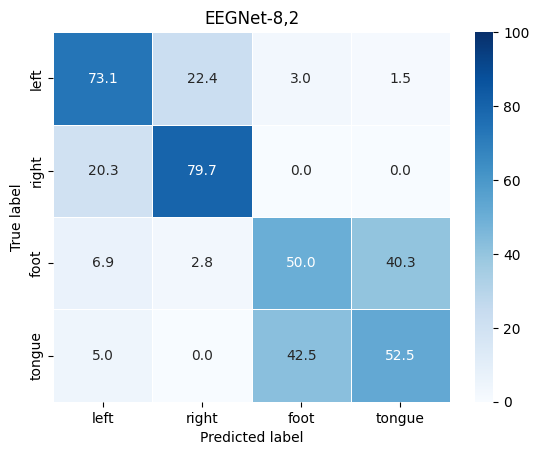

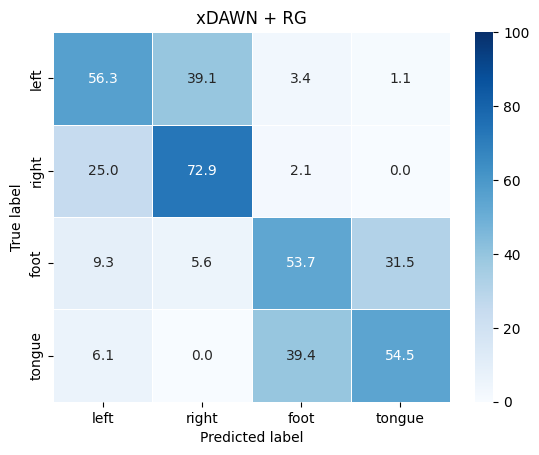

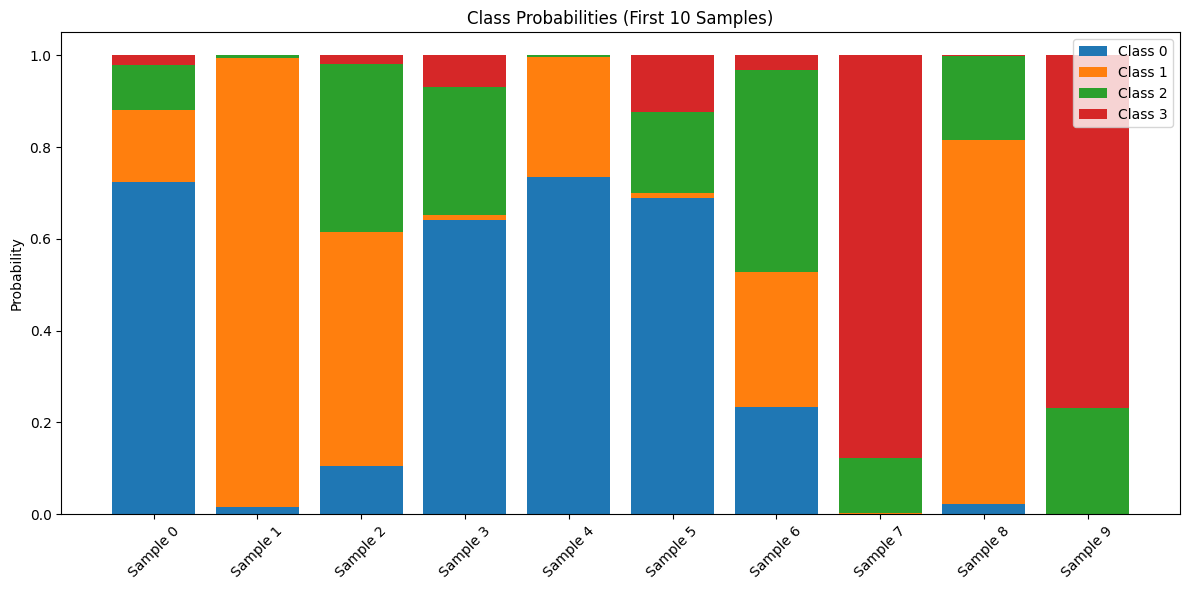

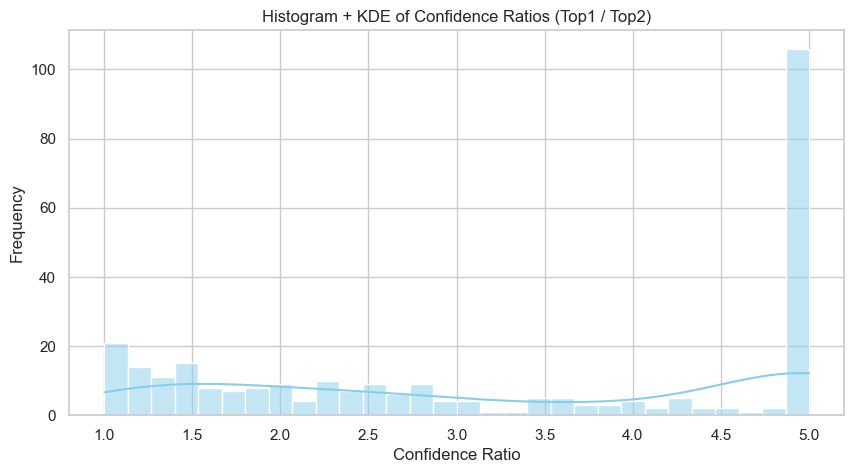

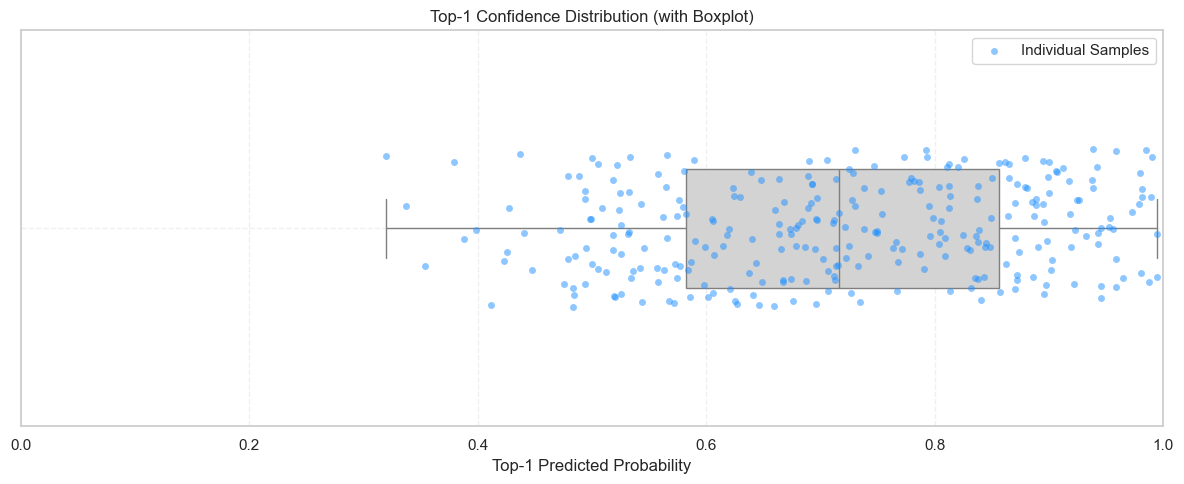

Average confidence of selected class:  0.71786755


In [10]:
#########################################################################################################

# load optimal weights
model.load_weights('/tmp/checkpoint.h5')

#predict
print(model.summary())
probs = model.predict(X_test)

#k=1.2 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
# k >= 1

#preds, Y_test, mask = accept_confident_probabilities(probs, k, Y_test)
#omitted = X_test[~mask]

preds = probs.argmax(axis = -1)

acc = np.mean(preds == Y_test.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
#print(len(omitted), " samples deleted")

plt.figure(0)
plot_confusion_matrix(preds, Y_test.argmax(axis = -1), names, title = 'EEGNet-8,2')


if input_format == "timeseries":
    util.xdawnrg(X_train, X_test, Y_train, Y_test, chans, samples, names)

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)
util.plot_prediction_confidence(probs)
util.plot_all_predicted_probabilities(probs)
print("Average confidence of selected class: ", np.mean(probs.max(axis=1)))
